# Operator Dynamics in Random Bricklayer Circuits with Pauli Propagation and MPO

The goal of this notebook is to study the time evolution of a local quantum observable using the Pauli propagation framework implemented in `PauliPropagation.jl` and compare it to the exact diagonalisation and MPO method.



In [376]:
# using Pkg; Pkg.add("LaTeXStrings"); Pkg.add("PauliPropagation"); Pkg.add("ITensors"); Pkg.add("ITensorMPS")

In [377]:
using LaTeXStrings
using Plots
using LinearAlgebra
import Statistics: mean

# --- Pauli Propagation ---
using PauliPropagation

#include("../src/pauli_propagation_functions.jl")
include("pauli_propagation_functions.jl")
import .pauli_propagation_functions as pp

# --- MPO ---
using ITensors, ITensorMPS

#include("../src/matrix_product_operator_functions.jl")
include("matrix_product_operator_functions.jl")
import .mpo_functions as mpo

# --- Exact method ---

#include("../src/exact_functions.jl")
include("exact_functions.jl")
import .exact_functions as ext

---

# 1. Random Gate Circuit

We will use a random circuits of the form:

$$
U = \prod_j e^{i \theta_j P_j}
$$

where:

- $\theta_j$ are random angles
- $P_j$ are random two-qubit Pauli strings

We need a **uniform distribution** for these random doors, so we will use the **Haar distribution**.

---

## 1.1 Mezzadri algo for Haar distribution

1.  **Generation of $Z$**: We create an $n \times n$ matrix where each element is a complex number $a + ib$, with $a, b \sim \mathcal{N}(0, 1)$.
2.  **QR decomposition**: We compute $Q$ and $R$ such that $Z = QR$.
3.  **Phase correction**: We define a diagonal matrix $\Lambda$ such that:
$$\Lambda_{ii} = \frac{R_{ii}}{|R_{ii}|}$$
  The diagonal elements of $R' = \Lambda^{-1}R$ are always real and strictly positive, therefore the matrix $Q' = Q\Lambda$ is **distributed with Haar measure**.

We then compute the final unitary matrix: $U = Q \times \Lambda$.



In [378]:
function haar_unitary(n::Int64)
    # 1. Generation of Z
    Z = randn(ComplexF64, n, n)

    # 2. QR Decomposition
    F = qr(Z)
    Q = Matrix(F.Q)
    R = F.R

    # 3. Phase correction
    d = diag(R)
    ph = d ./ abs.(d)

    U = Q * Diagonal(ph)
    @assert U * U' ≈ U' * U ≈ I(n) # verify U is a nxn unitary matrix
    return U
end

haar_unitary (generic function with 1 method)

And we verify if $U$ is unitary with `@assert U * U' ≈ U' * U ≈ I(4)`.

---

## 1.2 Matrices to gates

Now we want to use these random unitary matrices as gates to build a quantum circuit of the type :

<img src="https://github.com/TheoHUETQC/Quantum-ManyBody-Sim-Methods/blob/main/figures/brickwork_pattern_circuit.png?raw=1" width="600" alt="Block circuit">

All U are different random 4x4 matrices.

For the PauliPropagation method, the package allows us to do this using the function `TransferMapGate()`.

In [379]:
function random_block_gate(pair::Tuple{Int64, Int64}, nqubits::Int64)
  # need to be 4x4 and unitary
  #U = random_unitary_matrix()
  U = haar_unitary(4)
  # U = [0 0 0 1; 0 0 1 0; 0 1 0 0; 1 0 0 0] # XX gate for test

  # --- Pauli Propagation ---
  U_ptm = calculateptm(U)
  U_pp = TransferMapGate(U_ptm, pair)

  # --- MPO ---
  i, j = pair
  s1, s2 = sites[i], sites[j]
  U_mpo = itensor(U, s2', s1', s2, s1) # itensor(U, s1', s2', s1, s2)

  # --- Exact ---
  U_exact = [1.0 + 0.0im;;]
  k = 1
  while k <= nqubits
      if k == i
          # Si on arrive à l'indice de la paire on applique la porte U (4x4)
          U_exact = kron(U_exact, U)
          k += 2  # On saute le qubit suivant puisqu'il est inclus dans U
      else
          U_exact = kron(U_exact, I(2))
          k += 1
      end
  end

  return U_pp, U_mpo, U_exact
end

random_block_gate (generic function with 1 method)

---

## 1.3 Random Circuit

In [380]:
function random_brick_circuit(nqubits::Integer, nlayers::Integer; topology=nothing)
    circuit_pp::Vector{Gate} = []
    circuit_mpo::Vector{Vector{ITensor}} = []
    circuit_exact::Vector{Vector{Matrix}} = []

    if isnothing(topology)
        topology = bricklayertopology(nqubits; periodic=false)
    end

    for _ in 1:nlayers
      layer_mpo::Vector{ITensor} = []
      layer_exact::Vector{Matrix} = []
      for pair in topology
          U_pp, U_mpo, U = random_block_gate(pair, nqubits)
          push!(circuit_pp, U_pp)
          push!(layer_mpo, U_mpo)
          push!(layer_exact, U)
      end
      push!(circuit_mpo, layer_mpo)
      push!(circuit_exact, layer_exact)
    end
    return circuit_pp, circuit_mpo, circuit_exact
end

random_brick_circuit (generic function with 1 method)

---

# 2. test the implementation of the circuit

## 2.1 initialisation

In [381]:
nqubits = 8
nlayers = 100

topology = bricklayertopology(nqubits; periodic=false)

# creation des sites, on a besoin de l'init avant le circuit
sites = ITensors.siteinds("Qubit", nqubits)

# define the circuit
circuit_pp, circuit_mpo, circuit_exact = random_brick_circuit(nqubits, nlayers; topology)

# for Z_i
i= nqubits ÷ 2

4

### Exact

In [382]:
# psi0
ψ0_exact =  ψ0_pp # |0> state

# Z_i
Z_i_exact = ext.get_Zi(nqubits, i)

256×256 Matrix{ComplexF64}:
 1.0+0.0im  0.0+0.0im  0.0+0.0im  …   0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  1.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  1.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …   0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …   0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
    ⋮                             ⋱ 

### Pauli Propagation

In [383]:
# the truncations
max_weight = nqubits
min_abs_coeff = 0.

# psi0
ψ0_pp = append!([1.],[0. for _ in 2:(2^nqubits)]) # |0> state

# Z_i
Z_i_pp = PauliString(nqubits, :Z, i) # I...IZI...I

PauliString(nqubits: 8, 1.0 * IIIZIIII)

### MPO

In [384]:
"""# the truncations
cutoff = 0.
maxdim = 2^nqubits

# psi0
ψ0_mps = MPS(sites, ["Up" for _ in 1:nqubits]) # |↑↑..↑>

# Z_i
ops = ["Id" for n in 1:nqubits]
ops[i] = "Z"
Z_i_mpo = MPO(sites, ops)"""

"# the truncations\ncutoff = 0.\nmaxdim = 2^nqubits\n\n# psi0\nψ0_mps = MPS(sites, [\"Up\" for _ in 1:nqubits]) # |↑↑..↑>\n\n# Z_i\nops = [\"Id\" for n in 1:nqubits]\nops[i] = \"Z\"\nZ_i_mpo = MPO(sites, ops)"

---

## 2.2 Propagation

In [385]:
println("Exact method")
Z_it_exact, result_exact = ext.propagate_layerbylayer(circuit_exact, Z_i_exact; ψ0=ψ0_exact)
println("---")

Exact method
layer : 10 /100 complete
layer : 20 /100 complete
layer : 30 /100 complete
layer : 40 /100 complete
layer : 50 /100 complete
layer : 60 /100 complete
layer : 70 /100 complete
layer : 80 /100 complete
layer : 90 /100 complete
layer : 100 /100 complete
Time taken by ext.propagate_layerbylayer: 6.178493976593018 seconds
---


In [386]:
println("Pauli Propagation method")
Z_it_pp, result_pp = pp.propagate_layerbylayer(circuit_pp, Z_i_pp, nlayers; max_weight, min_abs_coeff, ψ0=ψ0_pp)
println("---")

Pauli Propagation method
layer : 10/100 complete
layer : 20/100 complete
layer : 30/100 complete
layer : 40/100 complete
layer : 50/100 complete
layer : 60/100 complete
layer : 70/100 complete
layer : 80/100 complete
layer : 90/100 complete
layer : 100/100 complete
Time taken by pp.propagate_layerbylayer: 94.09344100952148 seconds
---


In [387]:
"""println("Matrix Product Operator method")
Z_it_mpo, result_mpo = mpo.propagate_layerbylayer(circuit_mpo, Z_i_mpo; cutoff, maxdim, ψ0=ψ0_mps)
println("---")"""

"println(\"Matrix Product Operator method\")\nZ_it_mpo, result_mpo = mpo.propagate_layerbylayer(circuit_mpo, Z_i_mpo; cutoff, maxdim, ψ0=ψ0_mps)\nprintln(\"---\")"

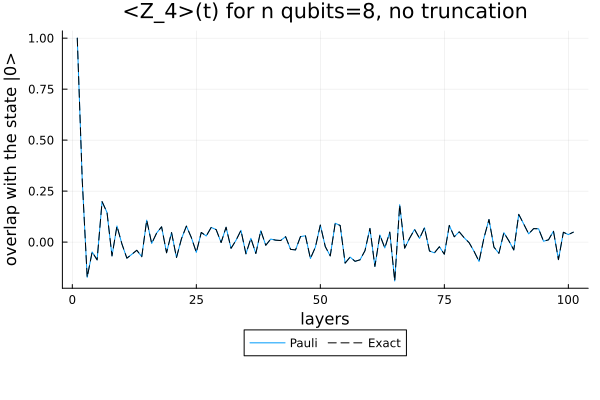

In [388]:
overlap_pp = result_pp["overlap"]
#overlap_mpo = result_mpo["overlap"]
overlap_exact = result_exact["overlap"]

p = plot(title="<Z_$i>(t) for n qubits=$nqubits, no truncation", xlabel="layers", ylabel="overlap with the state |0>")

plot!(p, 1:length(overlap_pp), overlap_pp, label="Pauli")
#plot!(p, 1:length(overlap_mpo), overlap_mpo, label="MPO")
plot!(p, 1:length(overlap_exact), overlap_exact, label="Exact", line = (1, :dash), color=:black)
plot!(legend=:outerbottom, legendcolumns=2)

display(p)

The MPO method give clearly wrong results.

---

# 3. Pauli Propagation method

## 3.1 Max weight

In [389]:
# the truncations
max_weight_list = round.(Int, range(nqubits-2, nqubits))
min_abs_coeff_idx = 6
min_abs_coeff = 10. ^(-min_abs_coeff_idx)

overlap_max_weight = Vector[]
for max_weight in max_weight_list
    println("---")
    println("Max weight : ",max_weight)
    pauli_sum, result = pp.propagate_layerbylayer(circuit_pp, Z_i_pp, nlayers; max_weight, min_abs_coeff, ψ0=ψ0_pp)
    push!(overlap_max_weight, result["overlap"])
end

---
Max weight : 6
layer : 10/100 complete
layer : 20/100 complete
layer : 30/100 complete
layer : 40/100 complete
layer : 50/100 complete
layer : 60/100 complete
layer : 70/100 complete
layer : 80/100 complete
layer : 90/100 complete
layer : 100/100 complete
Time taken by pp.propagate_layerbylayer: 68.98118281364441 seconds
---
Max weight : 7
layer : 10/100 complete
layer : 20/100 complete
layer : 30/100 complete
layer : 40/100 complete
layer : 50/100 complete
layer : 60/100 complete
layer : 70/100 complete
layer : 80/100 complete
layer : 90/100 complete
layer : 100/100 complete
Time taken by pp.propagate_layerbylayer: 83.08817601203918 seconds
---
Max weight : 8
layer : 10/100 complete
layer : 20/100 complete
layer : 30/100 complete
layer : 40/100 complete
layer : 50/100 complete
layer : 60/100 complete
layer : 70/100 complete
layer : 80/100 complete
layer : 90/100 complete
layer : 100/100 complete
Time taken by pp.propagate_layerbylayer: 92.92823696136475 seconds


---

### Plot and Result

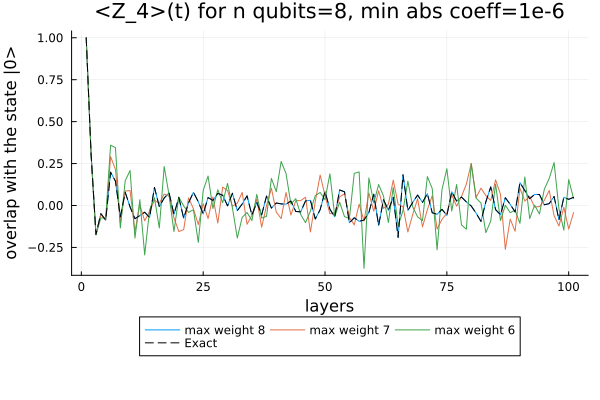

In [390]:
p = plot(title="<Z_$i>(t) for n qubits=$nqubits, min abs coeff=1e-$min_abs_coeff_idx", xlabel="layers", ylabel="overlap with the state |0>")

for (j, overlap) in enumerate(reverse(overlap_max_weight))
    plot!(p, 1:length(overlap), overlap, label="max weight $(reverse(max_weight_list)[j])")
end
plot!(p, 1:length(overlap_exact), overlap_exact, label="Exact", line = (1, :dash), color=:black)
plot!(legend=:outerbottom, legendcolumns=length(overlap_max_weight))

display(p)

### Observation

We observe that for a maximum weight below the number of Qubits, our method troncate $c_\alpha$ wich are important for the physical state.

This seems consistent with the type of circuit through which we propagate our observable.
Indeed, a circuit composed of random gates creates a lot of correlation between the qubits. Consequently, a max weight that is too small avoids strong correlations and thus takes us drastically away from the exact physical state, which is highly correlated.

---

### 3.2.2 Minimum absolute coefficient

In [391]:
# the truncations
max_weight = nqubits
min_abs_coeff_idx = round.(Int, range(2, 4))
min_abs_coeff_list = 10.0 .^ .-min_abs_coeff_idx

overlap_min_min_abs_coeff = Vector[]
for (j, min_abs_coeff) in enumerate(min_abs_coeff_list)
    println("---")
    println("Min abs coefficient: 1e-",min_abs_coeff_idx[j])
    pauli_sum, result = pp.propagate_layerbylayer(circuit_pp, Z_i_pp, nlayers; max_weight, min_abs_coeff, ψ0=ψ0_pp)
    push!(overlap_min_min_abs_coeff, result["overlap"])
end

---
Min abs coefficient: 1e-2
layer : 10/100 complete
layer : 20/100 complete
layer : 30/100 complete
layer : 40/100 complete
layer : 50/100 complete
layer : 60/100 complete
layer : 70/100 complete
layer : 80/100 complete
layer : 90/100 complete
layer : 100/100 complete
Time taken by pp.propagate_layerbylayer: 1.2537930011749268 seconds
---
Min abs coefficient: 1e-3
layer : 10/100 complete
layer : 20/100 complete
layer : 30/100 complete
layer : 40/100 complete
layer : 50/100 complete
layer : 60/100 complete
layer : 70/100 complete
layer : 80/100 complete
layer : 90/100 complete
layer : 100/100 complete
Time taken by pp.propagate_layerbylayer: 76.21480393409729 seconds
---
Min abs coefficient: 1e-4
layer : 10/100 complete
layer : 20/100 complete
layer : 30/100 complete
layer : 40/100 complete
layer : 50/100 complete
layer : 60/100 complete
layer : 70/100 complete
layer : 80/100 complete
layer : 90/100 complete
layer : 100/100 complete
Time taken by pp.propagate_layerbylayer: 96.53518486

---

### Plot and Result

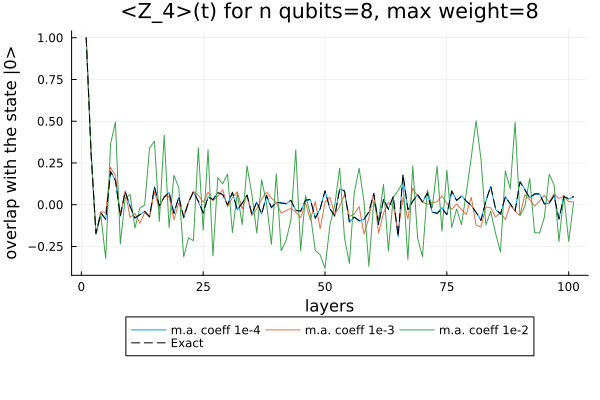

In [392]:
p = plot(title="<Z_$i>(t) for n qubits=$nqubits, max weight=$max_weight", xlabel="layers", ylabel="overlap with the state |0>")

for (i, overlap) in enumerate(reverse(overlap_min_min_abs_coeff))
    plot!(p, 1:length(overlap), overlap, label="m.a. coeff 1e-$(reverse(min_abs_coeff_idx)[i])")
end
plot!(p, 1:length(overlap_exact), overlap_exact, label="Exact", line = (1, :dash), color=:black)
plot!(legend=:outerbottom, legendcolumns=length(overlap_min_min_abs_coeff))

display(p)

### Observation

It is clear that we need a value smaller or equal than $10^{-4}$ for this circuit and this number of qubits.

---

## 3.3 Summary

For the next simulations, we can use the layer by layer propagation with :
- a maximum weight equal to **qubit's number**,
- a minimum absolute value of $10^{-4}$.

for 8 qubits

layer : 10/100 complete
layer : 20/100 complete
layer : 30/100 complete
layer : 40/100 complete
layer : 50/100 complete
layer : 60/100 complete
layer : 70/100 complete
layer : 80/100 complete
layer : 90/100 complete
layer : 100/100 complete
Time taken by pp.propagate_layerbylayer: 91.36822390556335 seconds


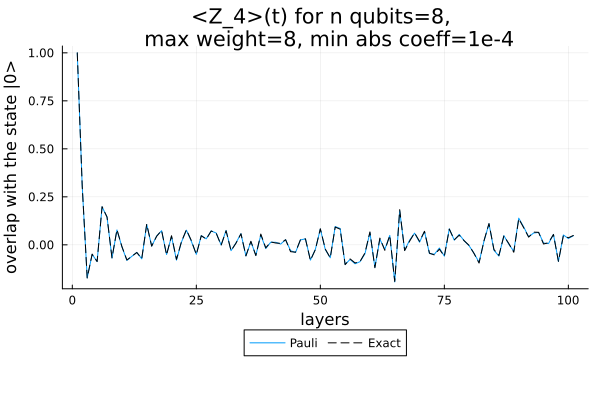

In [393]:
max_weight = nqubits
min_abs_coeff_idx = 4
min_abs_coeff = 10. ^(-min_abs_coeff_idx)

pauli_sum, result = pp.propagate_layerbylayer(circuit_pp, Z_i_pp, nlayers; max_weight, min_abs_coeff, ψ0=ψ0_pp)
overlap_mpo = result["overlap"]

p = plot(title="<Z_$i>(t) for n qubits=$nqubits, \n max weight=$max_weight, min abs coeff=1e-$min_abs_coeff_idx", xlabel="layers", ylabel="overlap with the state |0>")

plot!(p, 1:length(overlap_mpo), overlap_mpo, label="Pauli")
plot!(p, 1:length(overlap_exact), overlap_exact, label="Exact", line = (1, :dash), color=:black)

plot!(legend=:outerbottom, legendcolumns=2)

display(p)

Let's see if the propagate function from the package is faster than mine

In [394]:
t = time()
pauli_sum2 = propagate(circuit_pp, Z_i_pp; max_weight, min_abs_coeff)
dt = time()-t

102.84606695175171

In [405]:
matrix = pp.compute_matrix(pauli_sum)
matrix2 = pp.compute_matrix(pauli_sum2)

println(isapprox(matrix2, matrix; rtol=1e-1))
println(isapprox(Z_it_exact, matrix; rtol=1e-1))

true
true


In [ ]:
#isapprox(norm_temp, norm0; rtol=1e-3)

Time taken for 8 qubits, 100 layers
- 91.368 sec for Pauli
- 6.178 sec for Exact


---

# 4. Matrix Product Operator (MPO) method

(soon)

---

# 5. Thermalisation

In [397]:
therm_layer = nlayers ÷ 10 # we let 10% of the circuit for the system to be thermalized

10

## 5.1 Pauli Propagation

In [398]:
overlap_result_average = mean(overlap_mpo)
println(overlap_result_average)

0.01798724823411141


---

## 5.2 MPO

In [399]:
"""
ψ0_list = [random_mps(sites) for _ in 1:5]

overlap_result = Vector[]
for (i, ψ0) in enumerate(ψ0_list)
  println("---")
  println("ψ0[$i]")
  Z_it_mpo, result_mpo = mpo.propagate_layerbylayer(circuit_mpo, Z_i_mpo; cutoff, maxdim, ψ0)
  push!(overlap_result, result_mpo["overlap"][therm_layer:end])
end
"""

"ψ0_list = [random_mps(sites) for _ in 1:5]\n\noverlap_result = Vector[]\nfor (i, ψ0) in enumerate(ψ0_list)\n  println(\"---\")\n  println(\"ψ0[4]\")\n  Z_it_mpo, result_mpo = mpo.propagate_layerbylayer(circuit_mpo, Z_i_mpo; cutoff, maxdim, ψ0)\n  push!(overlap_result, result_mpo[\"overlap\"][therm_layer:end])\nend\n"

In [400]:
"""overlap_result_average = mean.(overlap_result)

p = plot(title="average <Z_$i>(t) for different random initial states", ylabel="overlap with random state")

scatter!(p, 1:length(overlap_result_average), overlap_result_average, label="average <Z_i>(t)")
hline!([0], label="theoric value")
plot!(legend=:outerbottom, legendcolumns=2)

display(p)"""

"overlap_result_average = mean.(overlap_result)\n\np = plot(title=\"average <Z_4>(t) for different random initial states\", ylabel=\"overlap with random state\")\n\nscatter!(p, 1:length(overlap_result_average), overlap_result_average, label=\"average <Z_i>(t)\")\nhline!([0], label=\"theoric value\")\nplot!(legend=:outerbottom, legendcolumns=2)\n\ndisplay(p)"

---

## References

- https://arxiv.org/abs/2505.21606
- https://github.com/MSRudolph/PauliPropagation.jl
- https://cheatsheet.juliadocs.org/
- https://arxiv.org/abs/math-ph/0609050
- [Julia documentation](https://docs.julialang.org/en/v1/)
- [Plots documentation](https://docs.juliaplots.org/stable/)
- [LinearAlgebra documentation](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/)
- [LaTeXStrings documentation](https://juliapackages.com/p/latexstrings)
- Latex Tiks documentation https://www.overleaf.com/learn/latex/LaTeX_Graphics_using_TikZ%3A_A_Tutorial_for_Beginners_(Part_3)%E2%80%94Creating_Flowcharts
